# 02_preprocessing_evaluation.ipynb

Evaluate wearable signals before and after preprocessing.

Goals:
- Visualize raw physiological signals
- Inspect missing data behavior
- Compare raw vs smoothed signals
- Build intuition around wearable preprocessing pipelines


## Imports

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Allow notebook to import from src/
# --------------------------------------------------

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


from src.data_generation import generate_wearable_data

from src.preprocessing import (
    add_timestamps,
    inject_missing_values,
    interpolate_signals,
    smooth_signals,
    preprocess_data
)


plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

## Generate Raw Synthetic Data

In [2]:
df_raw = generate_wearable_data(days=3)

df_raw = add_timestamps(df_raw)

print(df_raw.head())

print(f"\nDataset shape: {df_raw.shape}")

   minute         hr        hrv  activity  sleep_state           timestamp
0       0  36.711058  73.014932  0.002865          2.0 2024-01-01 00:00:00
1       1  39.033535  66.031370  0.002161          2.0 2024-01-01 00:01:00
2       2  38.413170  64.878082  0.012069          2.0 2024-01-01 00:02:00
3       3  41.277121  62.331668  0.000000          2.0 2024-01-01 00:03:00
4       4  35.905648  65.197242  0.000000          2.0 2024-01-01 00:04:00

Dataset shape: (4320, 6)


## Raw Signal Overview

Expected behavior:

- HR should show circadian structure + exercise spikes
- HRV should inversely track HR
- Activity should remain low during sleep
- Sleep stages should follow nightly structure


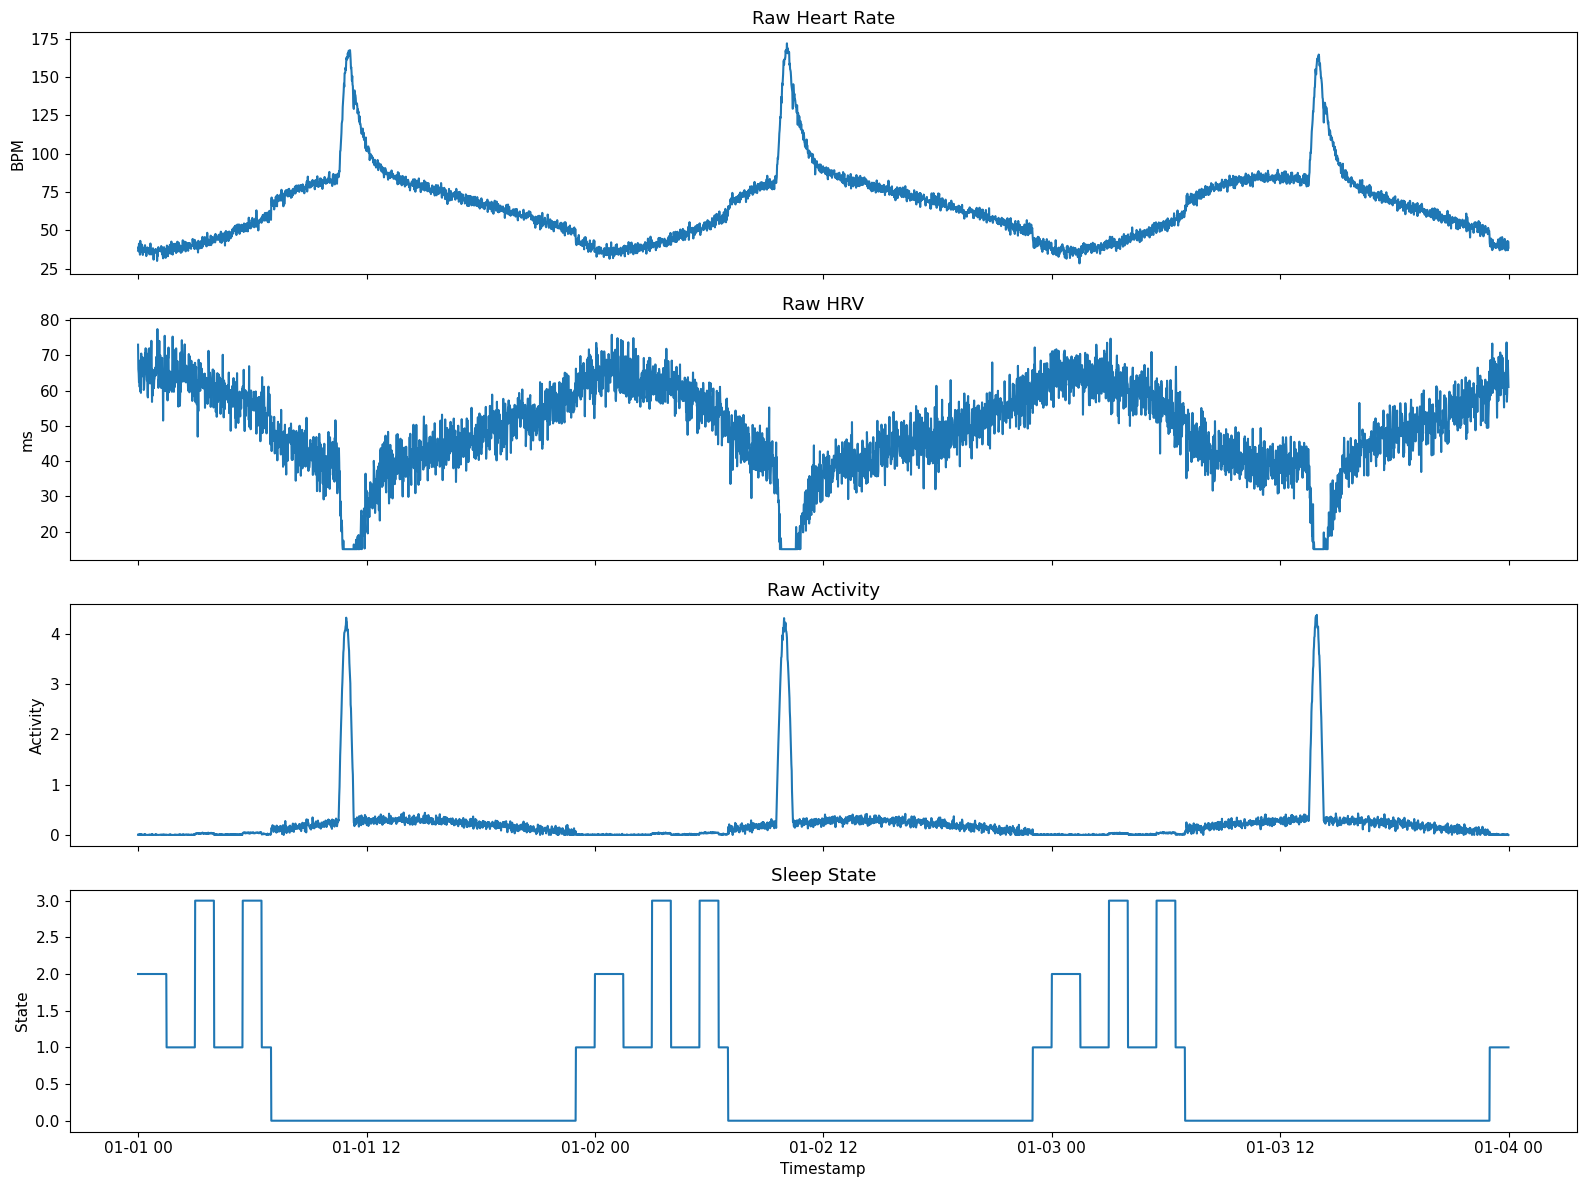

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# --------------------------------------------------
# Heart Rate
# --------------------------------------------------

axes[0].plot(df_raw["timestamp"], df_raw["hr"])
axes[0].set_title("Raw Heart Rate")
axes[0].set_ylabel("BPM")


# --------------------------------------------------
# HRV
# --------------------------------------------------

axes[1].plot(df_raw["timestamp"], df_raw["hrv"])
axes[1].set_title("Raw HRV")
axes[1].set_ylabel("ms")


# --------------------------------------------------
# Activity
# --------------------------------------------------

axes[2].plot(df_raw["timestamp"], df_raw["activity"])
axes[2].set_title("Raw Activity")
axes[2].set_ylabel("Activity")


# --------------------------------------------------
# Sleep State
# --------------------------------------------------

axes[3].plot(df_raw["timestamp"], df_raw["sleep_state"])
axes[3].set_title("Sleep State")
axes[3].set_ylabel("State")
axes[3].set_xlabel("Timestamp")


plt.tight_layout()
plt.show()

## Inject Missing Data

Real wearable datasets often contain:

- sensor dropout
- charging gaps
- motion artifacts
- Bluetooth interruptions

This step simulates missing samples.

In [4]:
df_missing = inject_missing_values(df_raw, missing_fraction=0.01)

missing_summary = df_missing.isna().sum()

print(missing_summary)

minute          0
hr             43
hrv            43
activity       43
sleep_state     0
timestamp       0
dtype: int64


## Visualize Missing Data

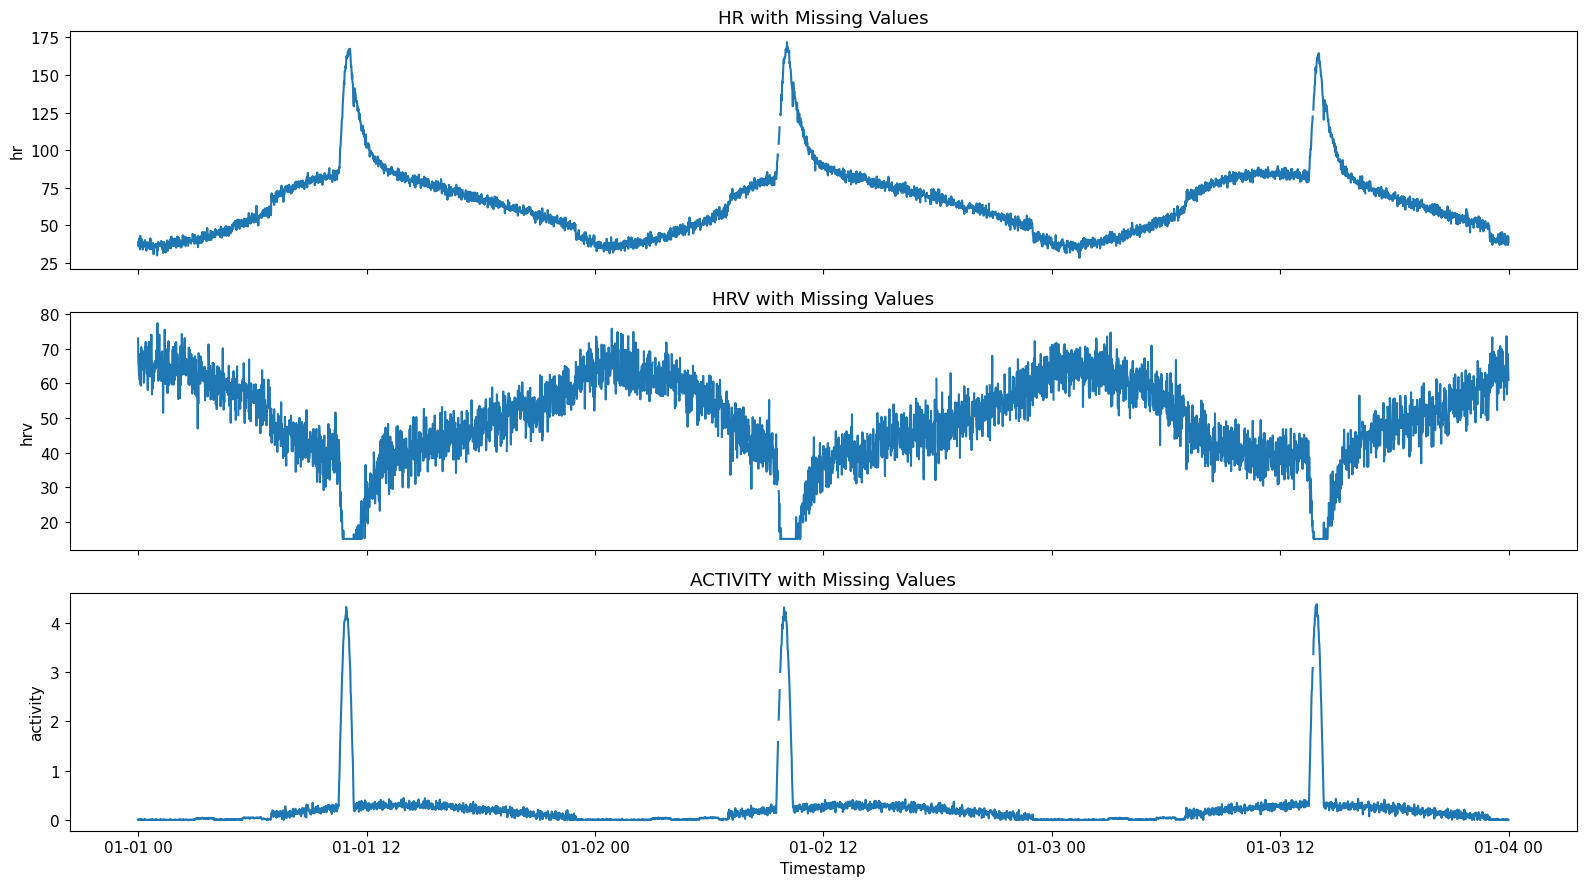

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

signals = ["hr", "hrv", "activity"]

for ax, signal in zip(axes, signals):

    ax.plot(df_missing["timestamp"], df_missing[signal])

    ax.set_title(f"{signal.upper()} with Missing Values")
    ax.set_ylabel(signal)

axes[-1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## Interpolate Missing Data

Linear interpolation estimates missing samples using neighboring values.

This is common in wearable preprocessing pipelines when gaps are short.

In [6]:
df_interpolated = interpolate_signals(df_missing)

print(df_interpolated.isna().sum())

minute         0
hr             0
hrv            0
activity       0
sleep_state    0
timestamp      0
dtype: int64


## Compare Raw vs Interpolated Signals

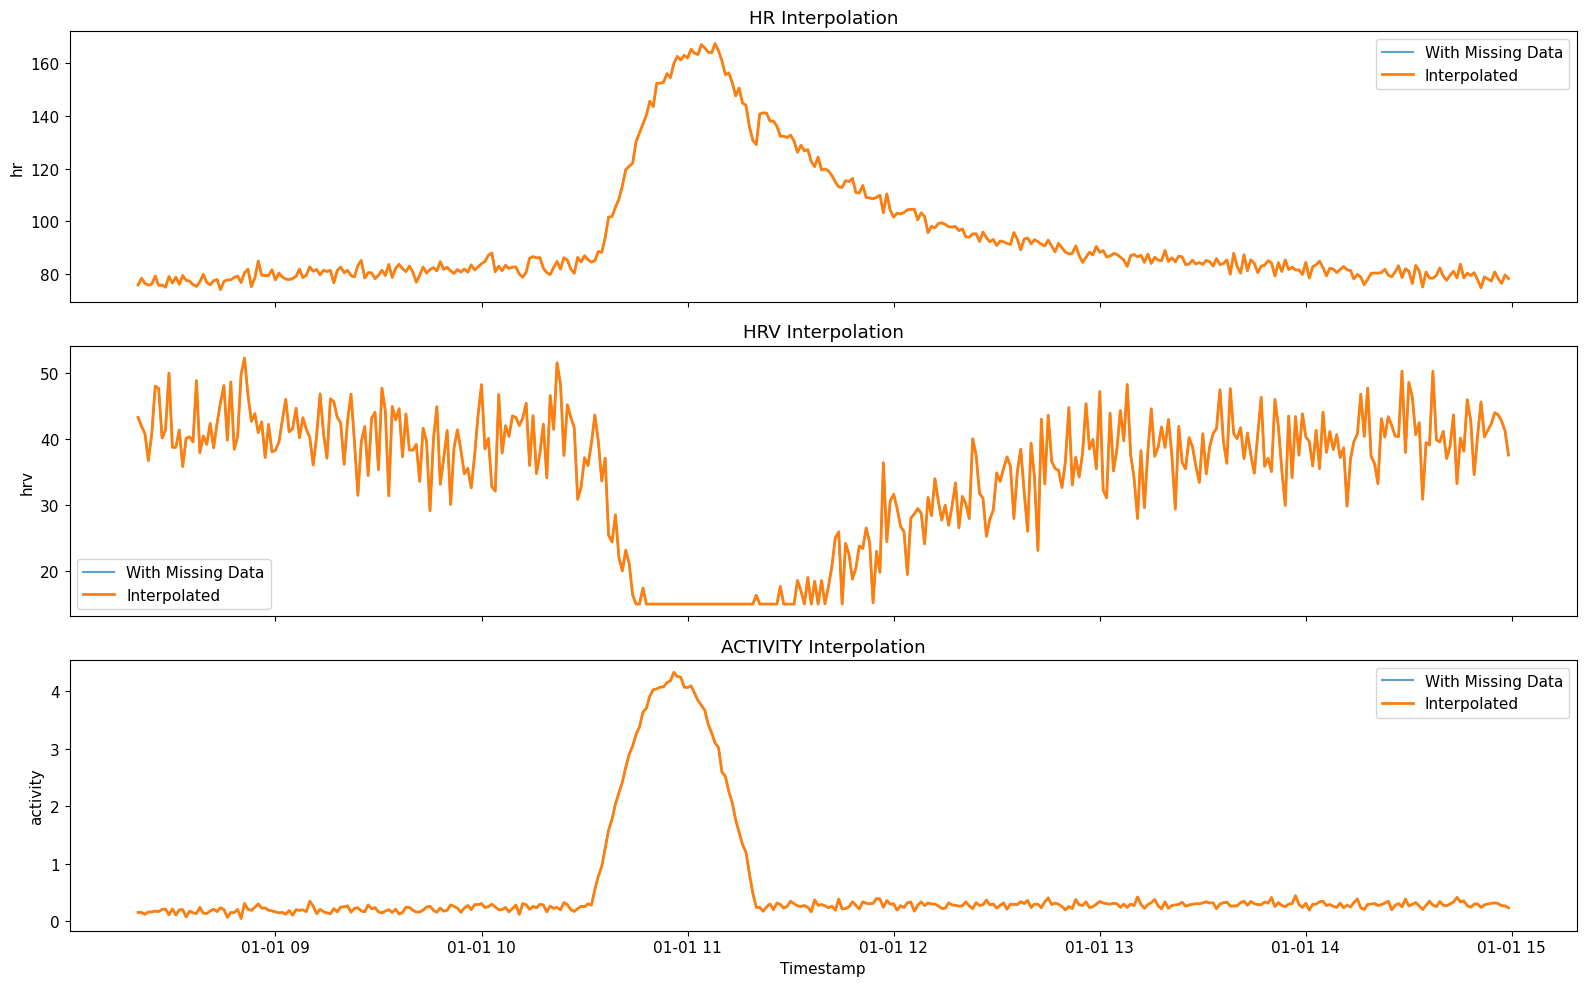

In [7]:
start_idx = 500
end_idx = 900


fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

signals = ["hr", "hrv", "activity"]

for ax, signal in zip(axes, signals):

    ax.plot(
        df_missing["timestamp"].iloc[start_idx:end_idx],
        df_missing[signal].iloc[start_idx:end_idx],
        label="With Missing Data",
        alpha=0.7
    )

    ax.plot(
        df_interpolated["timestamp"].iloc[start_idx:end_idx],
        df_interpolated[signal].iloc[start_idx:end_idx],
        label="Interpolated",
        linewidth=2
    )

    ax.set_title(f"{signal.upper()} Interpolation")
    ax.set_ylabel(signal)
    ax.legend()

axes[-1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## Smooth Physiological Signals

Wearable signals are noisy.

Rolling averages help:

- reduce sensor noise
- improve downstream feature stability
- better expose physiological trends

Tradeoff:
- too much smoothing can remove important dynamics

In [8]:
df_smoothed = smooth_signals(df_interpolated, window=5)

print(df_smoothed.head())

   minute         hr        hrv  activity  sleep_state           timestamp  \
0       0  36.711058  73.014932  0.002865          2.0 2024-01-01 00:00:00   
1       1  39.033535  66.031370  0.002161          2.0 2024-01-01 00:01:00   
2       2  38.413170  64.878082  0.012069          2.0 2024-01-01 00:02:00   
3       3  41.277121  62.331668  0.000000          2.0 2024-01-01 00:03:00   
4       4  35.905648  65.197242  0.000000          2.0 2024-01-01 00:04:00   

   hr_smooth  hrv_smooth  activity_smooth  
0        NaN         NaN              NaN  
1        NaN         NaN              NaN  
2  38.268106   66.290659         0.003419  
3  38.639084   63.901807         0.004955  
4  37.648479   63.092226         0.004523  


## Compare Raw vs Smoothed Signals

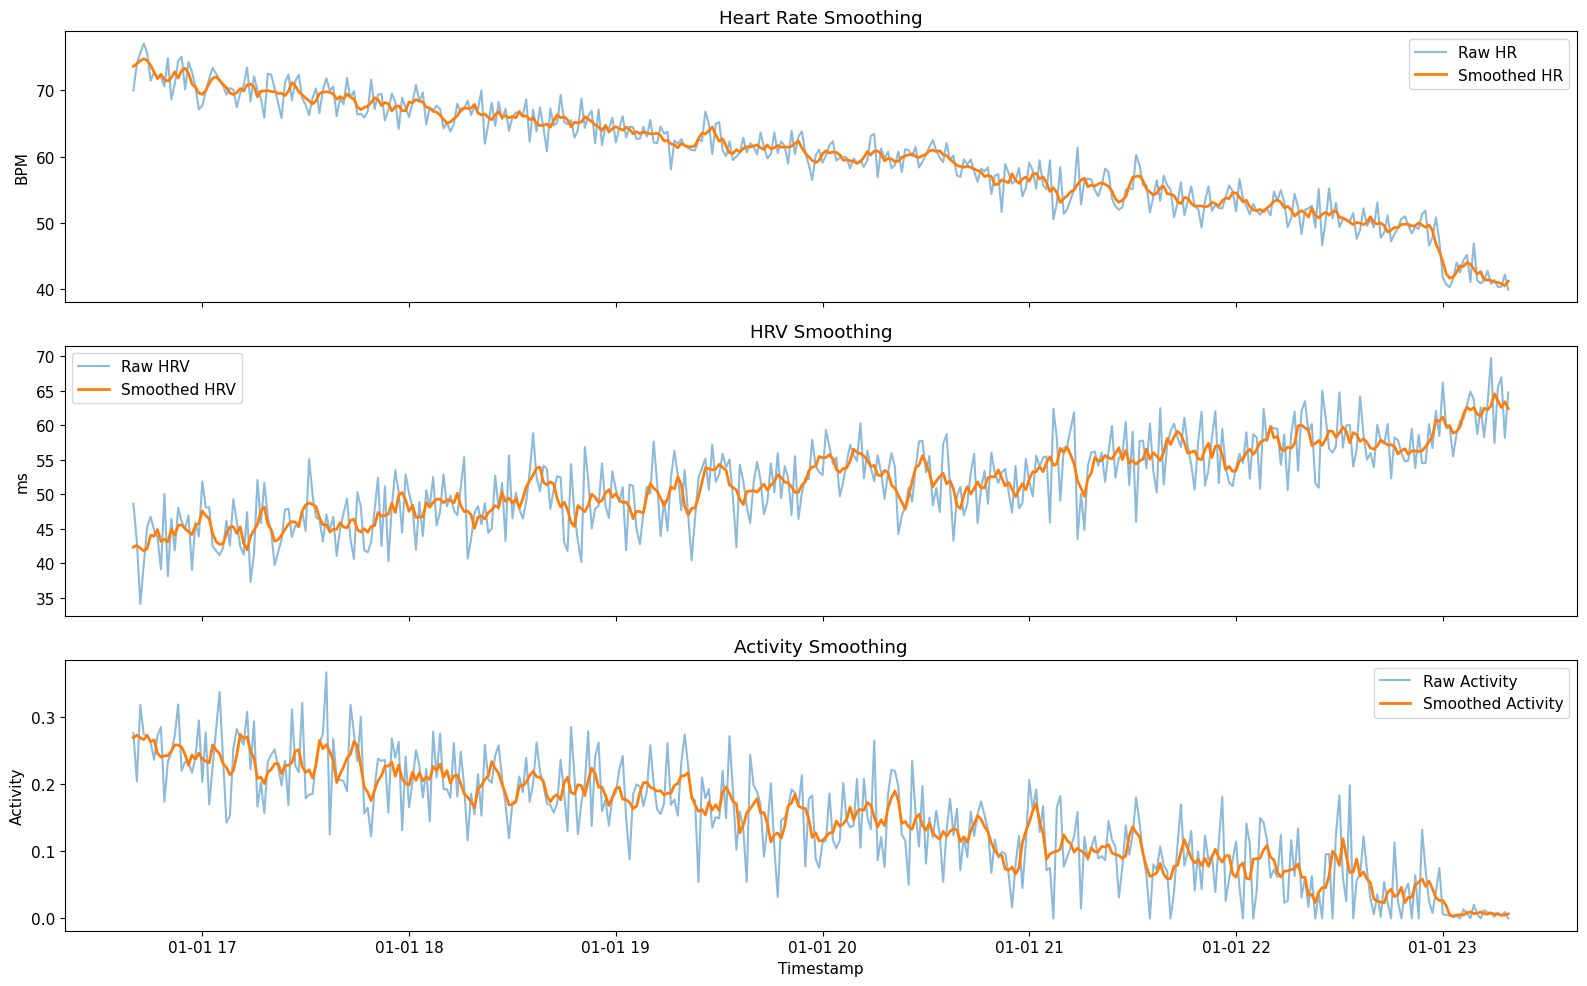

In [9]:
start_idx = 1000
end_idx = 1400


fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)


# --------------------------------------------------
# HR
# --------------------------------------------------

axes[0].plot(
    df_smoothed["timestamp"].iloc[start_idx:end_idx],
    df_smoothed["hr"].iloc[start_idx:end_idx],
    label="Raw HR",
    alpha=0.5
)

axes[0].plot(
    df_smoothed["timestamp"].iloc[start_idx:end_idx],
    df_smoothed["hr_smooth"].iloc[start_idx:end_idx],
    label="Smoothed HR",
    linewidth=2
)

axes[0].set_title("Heart Rate Smoothing")
axes[0].set_ylabel("BPM")
axes[0].legend()


# --------------------------------------------------
# HRV
# --------------------------------------------------

axes[1].plot(
    df_smoothed["timestamp"].iloc[start_idx:end_idx],
    df_smoothed["hrv"].iloc[start_idx:end_idx],
    label="Raw HRV",
    alpha=0.5
)

axes[1].plot(
    df_smoothed["timestamp"].iloc[start_idx:end_idx],
    df_smoothed["hrv_smooth"].iloc[start_idx:end_idx],
    label="Smoothed HRV",
    linewidth=2
)

axes[1].set_title("HRV Smoothing")
axes[1].set_ylabel("ms")
axes[1].legend()


# --------------------------------------------------
# Activity
# --------------------------------------------------

axes[2].plot(
    df_smoothed["timestamp"].iloc[start_idx:end_idx],
    df_smoothed["activity"].iloc[start_idx:end_idx],
    label="Raw Activity",
    alpha=0.5
)

axes[2].plot(
    df_smoothed["timestamp"].iloc[start_idx:end_idx],
    df_smoothed["activity_smooth"].iloc[start_idx:end_idx],
    label="Smoothed Activity",
    linewidth=2
)

axes[2].set_title("Activity Smoothing")
axes[2].set_ylabel("Activity")
axes[2].set_xlabel("Timestamp")
axes[2].legend()


plt.tight_layout()
plt.show()

## Run Full Preprocessing Pipeline

In [10]:
df_processed = preprocess_data(
    generate_wearable_data(days=3)
)

print(df_processed.columns)

df_processed.head()

Index(['minute', 'hr', 'hrv', 'activity', 'sleep_state', 'timestamp',
       'hr_smooth', 'hrv_smooth', 'activity_smooth'],
      dtype='object')


,minute,hr,hrv,activity,sleep_state,timestamp,hr_smooth,hrv_smooth,activity_smooth
0,0,36.711058,73.014932,0.002865,2.0,2024-01-01 00:00:00,NaN,NaN,NaN
1,1,39.033535,66.031370,0.002161,2.0,2024-01-01 00:01:00,NaN,NaN,NaN
2,2,38.413170,64.878082,0.012069,2.0,2024-01-01 00:02:00,NaN,NaN,NaN
3,3,41.277121,62.331668,0.000000,2.0,2024-01-01 00:03:00,NaN,NaN,NaN
4,4,35.905648,65.197242,0.000000,2.0,2024-01-01 00:04:00,NaN,NaN,NaN


## Before vs After Preprocessing

Final comparison of:

- raw physiological signal
- fully processed wearable signal


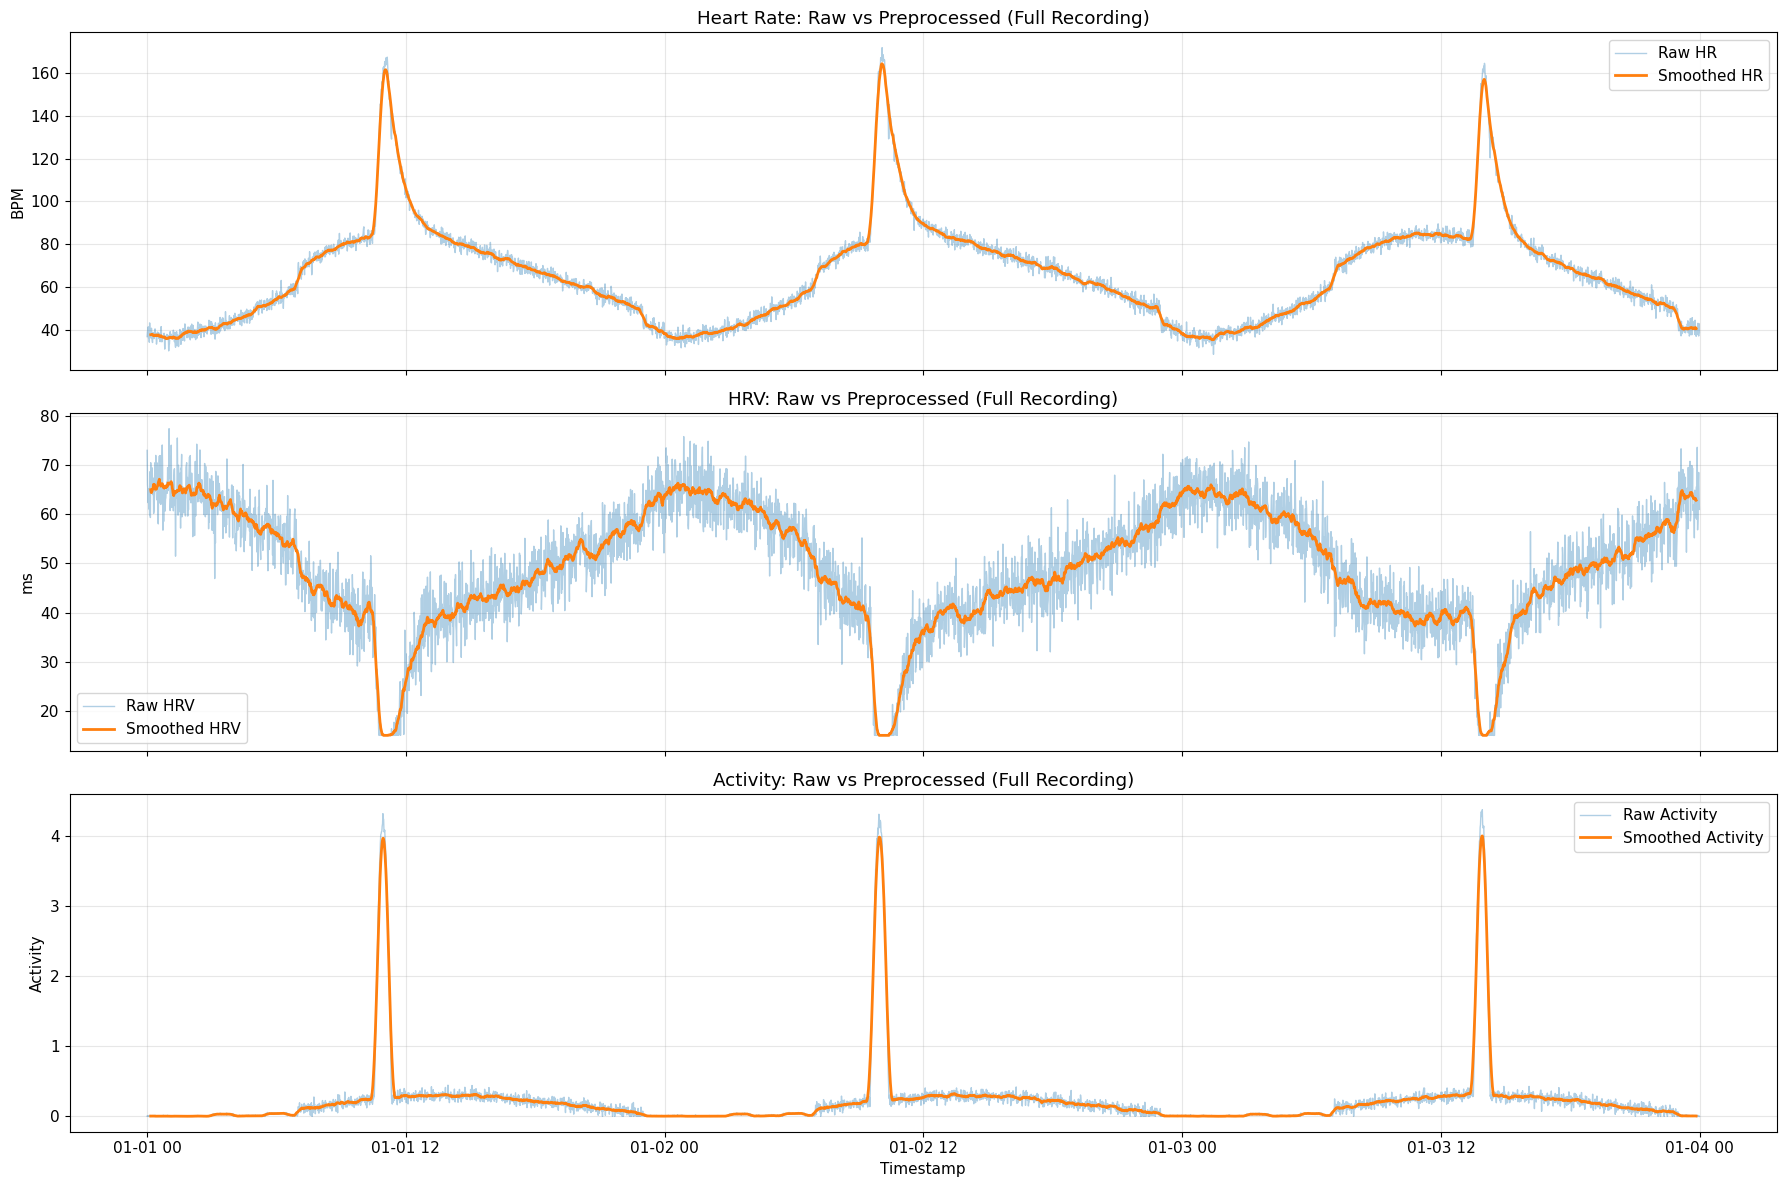

In [11]:
start_idx = 1200
end_idx = 1800


# ==================================================
# BEFORE VS AFTER PREPROCESSING (FULL MULTI-DAY VIEW)
# ==================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 12),
    sharex=True
)

# --------------------------------------------------
# HEART RATE
# --------------------------------------------------

axes[0].plot(
    df_processed["timestamp"],
    df_processed["hr"],
    label="Raw HR",
    alpha=0.35,
    linewidth=1
)

axes[0].plot(
    df_processed["timestamp"],
    df_processed["hr_smooth"],
    label="Smoothed HR",
    linewidth=2
)

axes[0].set_title(
    "Heart Rate: Raw vs Preprocessed (Full Recording)"
)

axes[0].set_ylabel("BPM")
axes[0].legend()


# --------------------------------------------------
# HRV
# --------------------------------------------------

axes[1].plot(
    df_processed["timestamp"],
    df_processed["hrv"],
    label="Raw HRV",
    alpha=0.35,
    linewidth=1
)

axes[1].plot(
    df_processed["timestamp"],
    df_processed["hrv_smooth"],
    label="Smoothed HRV",
    linewidth=2
)

axes[1].set_title(
    "HRV: Raw vs Preprocessed (Full Recording)"
)

axes[1].set_ylabel("ms")
axes[1].legend()


# --------------------------------------------------
# ACTIVITY
# --------------------------------------------------

axes[2].plot(
    df_processed["timestamp"],
    df_processed["activity"],
    label="Raw Activity",
    alpha=0.35,
    linewidth=1
)

axes[2].plot(
    df_processed["timestamp"],
    df_processed["activity_smooth"],
    label="Smoothed Activity",
    linewidth=2
)

axes[2].set_title(
    "Activity: Raw vs Preprocessed (Full Recording)"
)

axes[2].set_ylabel("Activity")
axes[2].set_xlabel("Timestamp")
axes[2].legend()


# --------------------------------------------------
# Formatting
# --------------------------------------------------

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Observations

Questions to think about:

- Did smoothing preserve exercise dynamics?
- Is the smoothing window too aggressive?
- How realistic are the missing-data gaps?
- Would real wearables use different interpolation methods?
- Which downstream features benefit most from preprocessing?

Potential future improvements:

- motion artifact simulation
- adaptive filtering
- frequency-domain filtering
- artifact detection
- confidence scores per signal
- realistic device dropout periods
